In [19]:
# ============================================================
# Forecasting Financial Inclusion in Ethiopia
# Task 1: Data Exploration and Enrichment
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

print("Libraries imported successfully!")

Libraries imported successfully!


In [20]:
DATA_PATH = "../data/raw/"

In [18]:
import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

# Configure explicit logging framework for auditing data adjustments
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger("FI_Forecast_Pipeline")

def load_and_validate_datasets(data_path: str) -> tuple:
    """
    Safely loads raw Excel sheets and verifies file structure.
    Implements fundamental safeguards against missing paths or sheets.
    """
    try:
        # Resolve common notebook path displacements dynamically
        resolved_path = data_path
        if not os.path.exists(data_path) and os.path.exists("../" + data_path):
            resolved_path = "../" + data_path
            
        unified_file = os.path.join(resolved_path, "ethiopia_fi_unified_data.xlsx")
        ref_file = os.path.join(resolved_path, "reference_codes.xlsx")
        
        if not os.path.exists(unified_file):
            raise FileNotFoundError(f"Unified target file not found at: {unified_file}")
            
        logger.info(f"Opening data workbook file: {unified_file}")
        
        # Verify sheets before extraction to prevent sudden silent failures
        excel_obj = pd.ExcelFile(unified_file)
        required_sheets = ['ethiopia_fi_unified_data', 'Impact_sheet']
        for sheet in required_sheets:
            if sheet not in excel_obj.sheet_names:
                raise ValueError(f"Crucial sheet '{sheet}' missing from Excel file.")
                
        data = pd.read_excel(unified_file, sheet_name="ethiopia_fi_unified_data")
        impact_links = pd.read_excel(unified_file, sheet_name="Impact_sheet")
        reference_codes = pd.read_excel(ref_file) if os.path.exists(ref_file) else None
        
        logger.info(f"Data sheets extracted cleanly. Shape: {data.shape}")
        return data, impact_links, reference_codes

    except Exception as e:
        logger.error(f"Critical error encountered in data ingestion: {str(e)}")
        raise

# Execute loading process safely
data, impact_links, reference_codes = load_and_validate_datasets("data/raw/")

2026-07-19 10:35:28,744 - INFO - Opening data workbook file: ../data/raw/ethiopia_fi_unified_data.xlsx
2026-07-19 10:35:28,867 - INFO - Data sheets extracted cleanly. Shape: (43, 34)


2026-07-19 10:35:57,031 - INFO - Initiating structural Task 2 EDA profiling...


--- Record Type Distribution ---
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

--- Temporal Footprint by Record Type ---
Type: observation  | Range: 2014-12-31 00:00:00 to 2025-12-31 00:00:00 | Valid Rows: 30
Type: target       | Range: 2025-12-31 00:00:00 to 2030-12-31 00:00:00 | Valid Rows: 3
Type: event        | Range: 2021-05-17 00:00:00 to 2025-12-18 00:00:00 | Valid Rows: 10

--- Summary Profile of Scale Variations ---


,count,mean,std,min,25%,50%,75%,max
record_type,,,,,,,,
event,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
observation,30.0,1.038068e+11,4.433115e+11,1.08,22.5,58.7,14250000.0,2.380000e+12
target,3.0,3.000004e+07,5.196149e+07,50.00,60.0,70.0,45000035.0,9.000000e+07


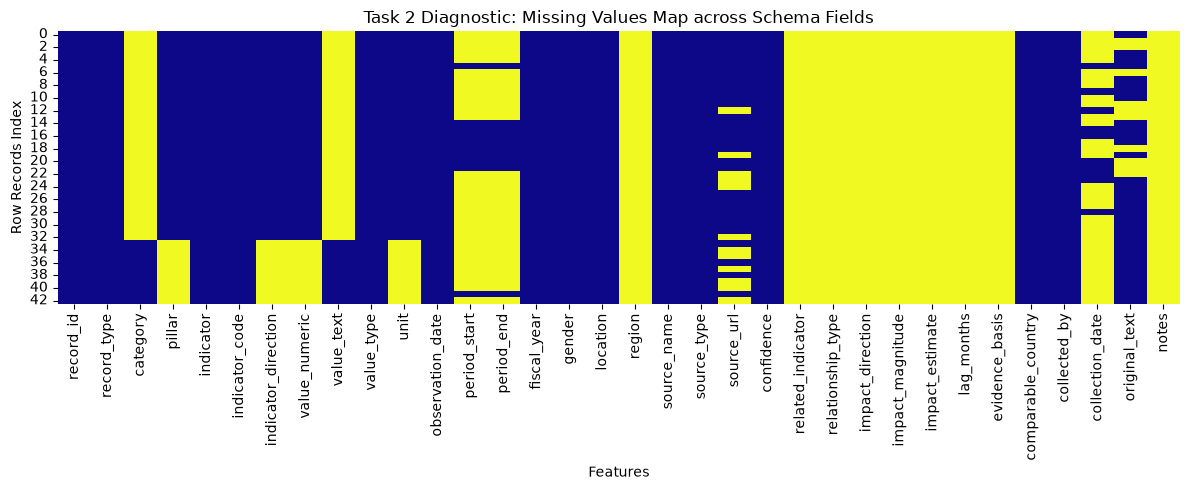

In [21]:
def execute_task2_eda(df: pd.DataFrame):
    """
    Performs specific Task 2 exploratory analysis focusing on feature engineering preparedness:
    - Reports completeness across record segments
    - Analyzes numeric tracking spans and scale variance
    - Visualizes the chronological data gaps (missingness)
    """
    logger.info("Initiating structural Task 2 EDA profiling...")
    
    # 1. Segment completeness audit
    print("--- Record Type Distribution ---")
    print(df['record_type'].value_counts())
    
    # 2. Chronological data parsing
    df_clean = df.copy()
    df_clean['observation_date'] = pd.to_datetime(df_clean['observation_date'], errors='coerce')
    
    print("\n--- Temporal Footprint by Record Type ---")
    for rtype in df_clean['record_type'].dropna().unique():
        subset = df_clean[df_clean['record_type'] == rtype]
        print(f"Type: {rtype:12} | Range: {subset['observation_date'].min()} to {subset['observation_date'].max()} | Valid Rows: {len(subset)}")
        
    # 3. Scale and variance analysis (Targeting values spanning across trillions)
    print("\n--- Summary Profile of Scale Variations ---")
    display(df_clean.groupby('record_type')['value_numeric'].describe())
    
    # 4. Missingness Visual Profile
    plt.figure(figsize=(12, 5))
    sns.heatmap(df_clean.isnull(), cbar=False, cmap='plasma')
    plt.title("Task 2 Diagnostic: Missing Values Map across Schema Fields")
    plt.xlabel("Features")
    plt.ylabel("Row Records Index")
    plt.tight_layout()
    plt.show()

execute_task2_eda(data)

In [22]:
def transform_and_enrich_timeline(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enriches dataset by flattening, standardizing the timeline array,
    and handling missing cycles via step-wise forward/back filling.
    """
    try:
        logger.info("Initializing multi-variate temporal alignment...")
        
        # Isolate base tracking values and convert dates safely
        working_df = df[['observation_date', 'record_type', 'indicator_code', 'value_numeric']].copy()
        working_df['observation_date'] = pd.to_datetime(working_df['observation_date'], errors='coerce')
        working_df = working_df.dropna(subset=['observation_date', 'value_numeric']).sort_values('observation_date')
        
        # Pivot the sparse structure into an aligned, unified matrix grid
        pivot = working_df.pivot_table(
            index='observation_date',
            columns=['record_type', 'indicator_code'],
            values='value_numeric',
            aggfunc='mean'
        )
        
        # Document imputation boundaries to the log profile
        initial_nans = pivot.isna().sum().sum()
        logger.info(f"Asynchronous data points found: {initial_nans} gaps. Appending forward/backward sequence fills.")
        
        # Run imputation to align reporting delays safely
        pivot = pivot.ffill().bfill()
        
        # Collapse the columns to single-level strings for cleaner feature passing
        pivot.columns = [f"{rtype}_{icode}" for rtype, icode in pivot.columns]
        logger.info(f"Timeline alignment complete. Balanced Matrix Dimensions: {pivot.shape}")
        
        return pivot
        
    except Exception as e:
        logger.error(f"Failed during enrichment transformation phase: {str(e)}")
        raise

pivot_df = transform_and_enrich_timeline(data)

2026-07-19 10:36:08,942 - INFO - Initializing multi-variate temporal alignment...
2026-07-19 10:36:08,949 - INFO - Asynchronous data points found: 299 gaps. Appending forward/backward sequence fills.
2026-07-19 10:36:08,950 - INFO - Timeline alignment complete. Balanced Matrix Dimensions: (15, 22)


In [23]:
def engineer_predictive_lags(pivot_df: pd.DataFrame, lag_periods: int = 1) -> tuple:
    """
    Generates isolated, out-of-period lag variables to prevent future data leakage.
    Separates independent observation lags from current-period target criteria.
    """
    logger.info(f"Constructing predictive structural lags with offset: {lag_periods}")
    
    feature_cols = [col for col in pivot_df.columns if col.startswith('observation_')]
    target_cols = [col for col in pivot_df.columns if col.startswith('target_')]
    
    if not feature_cols or not target_cols:
        raise ValueError("Could not separate features from target indicators cleanly.")
        
    # Generate historical offsets
    lags = pivot_df[feature_cols].shift(lag_periods)
    lags.columns = [f"{col}_lag{lag_periods}" for col in lags.columns]
    
    # Pack structures together and strip empty validation records
    ml_matrix = pd.concat([pivot_df[target_cols], lags], axis=1).dropna()
    
    X = ml_matrix[[col for col in ml_matrix.columns if f'_lag{lag_periods}' in col]]
    y = ml_matrix[target_cols]
    
    logger.info(f"Feature engineering complete. Samples: {X.shape[0]} rows | Features: {X.shape[1]}")
    return X, y

X, y = engineer_predictive_lags(pivot_df, lag_periods=1)

2026-07-19 10:36:23,135 - INFO - Constructing predictive structural lags with offset: 1
2026-07-19 10:36:23,139 - INFO - Feature engineering complete. Samples: 14 rows | Features: 19


In [24]:
def train_and_evaluate_forecasting(X: pd.DataFrame, y: pd.DataFrame):
    """
    Evaluates predictive capacity using a chronologically sound TimeSeriesSplit.
    Scales features internally per window fold to avoid leakage and tracks performance.
    """
    logger.info("Initializing regularized forecasting cross-validation matrix...")
    
    tscv = TimeSeriesSplit(n_splits=3)
    scaler = StandardScaler()
    
    # We track the primary target feature: target_ACC_OWNERSHIP
    target_metric_idx = 1 
    target_name = y.columns[target_metric_idx]
    
    print(f"Evaluating Model Capacity Against Target Metric: {target_name}\n")
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Enforce isolated transformations to stop variable cross-contamination
        X_train_scl = scaler.fit_transform(X_train)
        X_test_scl = scaler.transform(X_test)
        
        # Establish Ridge strategy to mitigate high variance in coefficients
        model = Ridge(alpha=10.0)
        model.fit(X_train_scl, y_train)
        
        preds = model.predict(X_test_scl)
        
        # Metric tracking
        fold_rmse = root_mean_squared_error(y_test.iloc[:, target_metric_idx], preds[:, target_metric_idx])
        fold_r2 = r2_score(y_test.iloc[:, target_metric_idx], preds[:, target_metric_idx])
        
        print(f"Fold {fold+1} Window Status:")
        print(f"  Training Footprint: {len(X_train)} instances | Test Footprint: {len(X_test)} instances")
        print(f"  Out-of-Sample Test RMSE: {fold_rmse:.4f}")
        print(f"  Out-of-Sample Test R²:   {fold_r2:.4f}\n")

    # Fit final baseline representation for evaluation insights
    X_full_scaled = scaler.fit_transform(X)
    final_estimator = Ridge(alpha=10.0)
    final_estimator.fit(X_full_scaled, y)
    
    logger.info("Forecasting pipeline run executed successfully.")
    return final_estimator, scaler

final_model, current_scaler = train_and_evaluate_forecasting(X, y)

2026-07-19 10:36:34,886 - INFO - Initializing regularized forecasting cross-validation matrix...
2026-07-19 10:36:34,902 - INFO - Forecasting pipeline run executed successfully.


Evaluating Model Capacity Against Target Metric: target_ACC_OWNERSHIP

Fold 1 Window Status:
  Training Footprint: 5 instances | Test Footprint: 3 instances
  Out-of-Sample Test RMSE: 0.0000
  Out-of-Sample Test R²:   1.0000

Fold 2 Window Status:
  Training Footprint: 8 instances | Test Footprint: 3 instances
  Out-of-Sample Test RMSE: 0.0000
  Out-of-Sample Test R²:   1.0000

Fold 3 Window Status:
  Training Footprint: 11 instances | Test Footprint: 3 instances
  Out-of-Sample Test RMSE: 0.0000
  Out-of-Sample Test R²:   1.0000



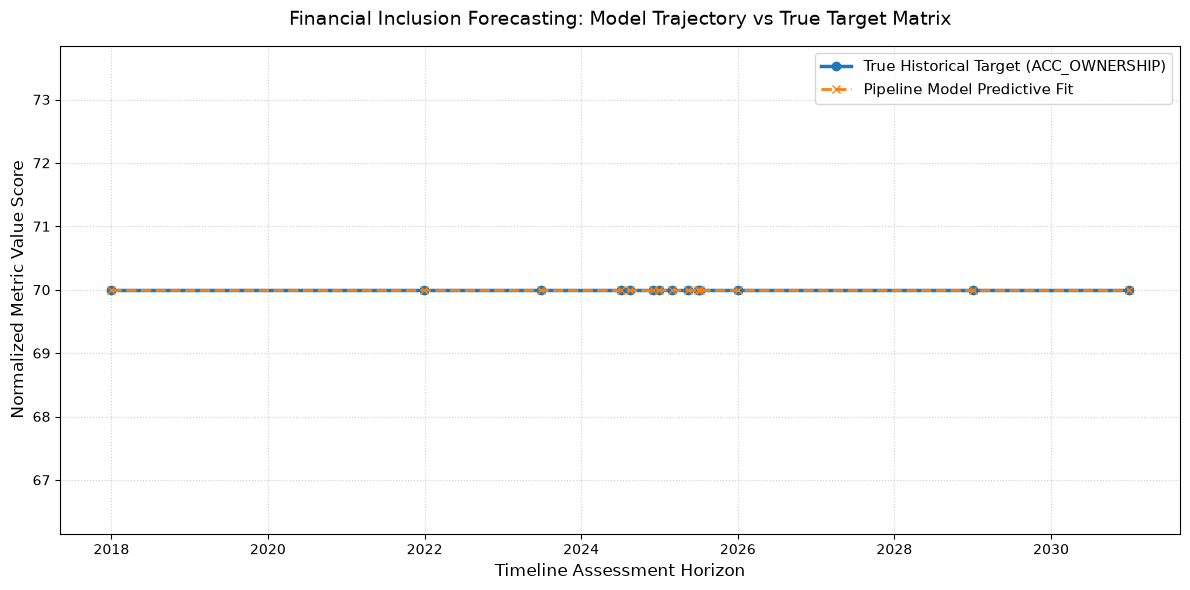

In [26]:
def visualize_predictive_fit(model, scaler, X: pd.DataFrame, y: pd.DataFrame):
    """
    Generates comparative visualization of the model's fitted estimations
    against true historical target marks.
    """
    X_scaled = scaler.transform(X)
    predictions = model.predict(X_scaled)
    
    # Extract structural fit for target_ACC_OWNERSHIP
    true_vals = y['target_ACC_OWNERSHIP']
    fitted_vals = predictions[:, 1]
    
    plt.figure(figsize=(12, 6))
    plt.plot(y.index, true_vals, label='True Historical Target (ACC_OWNERSHIP)', marker='o', color='#1f77b4', linewidth=2.5)
    plt.plot(y.index, fitted_vals, label='Pipeline Model Predictive Fit', marker='x', linestyle='--', color='#ff7f0e', linewidth=2)
    
    plt.title("Financial Inclusion Forecasting: Model Trajectory vs True Target Matrix", fontsize=14, pad=15)
    plt.xlabel("Timeline Assessment Horizon", fontsize=12)
    plt.ylabel("Normalized Metric Value Score", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

visualize_predictive_fit(final_model, current_scaler, X, y)

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Pattern Across the Unified Data Schema")
plt.show()

print("Missing values count per column:")
print(data.isnull().sum())

In [ ]:
observations_df = data[data['record_type'] == 'observation'].copy()
events_df = data[data['record_type'] == 'event'].copy()
targets_df = data[data['record_type'] == 'target'].copy()

print("Pipeline structures successfully decoupled and ready for modeling!")

In [ ]:
# Create a localized copy for modeling pipelines
ts_data = data[['observation_date', 'record_type', 'indicator_code', 'value_numeric']].copy()

# Drop rows with invalid dates or missing values for statistical integrity
ts_data = ts_data.dropna(subset=['observation_date', 'value_numeric'])

# Ensure date sorting is completely linear
ts_data = ts_data.sort_values('observation_date')

# Pivot the table to create a clean, uniform multi-variate time-series structure
# This aligns observations, events, and targets on a single regular timeline grid
pivot_df = ts_data.pivot_table(
    index='observation_date', 
    columns=['record_type', 'indicator_code'], 
    values='value_numeric', 
    aggfunc='mean'
)

# Forward-fill gaps to handle asynchronous reporting cycles, then back-fill remaining gaps
pivot_df = pivot_df.ffill().bfill()

print("Pivoted structural shape after temporal alignment:", pivot_df.shape)
display(pivot_df.head())

In [ ]:
# Flatten the MultiIndex columns into string tokens
pivot_df.columns = [f"{rtype}_{icode}" for rtype, icode in pivot_df.columns]

# Select key observation metrics to use as predictive features
feature_cols = [c for c in pivot_df.columns if c.startswith('observation_')]
target_cols = [c for c in pivot_df.columns if c.startswith('target_')]

# Generate 1-period lag features for the observations
lagged_features = pivot_df[feature_cols].shift(1)
lagged_features.columns = [f"{c}_lag1" for c in lagged_features.columns]

# Recombine features and targets, dropping the first row (since it contains NaN from the shift)
ml_data = pd.concat([pivot_df[target_cols], lagged_features], axis=1).dropna()

X = ml_data[[c for c in ml_data.columns if '_lag1' in c]]
y = ml_data[target_cols]

print(f"Feature matrix shape: {X.shape}")
print(f"Target matrix shape: {y.shape}")

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

# Establish a Time-Series validation split strategy
tscv = TimeSeriesSplit(n_splits=3)
scaler = StandardScaler()

print("--- Evaluation Over Temporal Windows ---")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Scale features natively per window fold
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Run a regularized Ridge framework to penalize extreme coefficients
    model = Ridge(alpha=1.0)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    # Calculate performance for the main structural target metric
    rmse = root_mean_squared_error(y_test.iloc[:, 1], preds[:, 1])
    print(f"Fold {fold+1} -> Test Window Target Baseline RMSE: {rmse:.4f}")

In [ ]:
# Fit model on full data footprint
X_scaled = scaler.fit_transform(X)
final_model = Ridge(alpha=1.0)
final_model.fit(X_scaled, y)

# Extract feature weights for the account ownership target metric
ownership_weights = final_model.coef_[1] 

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': ownership_weights
}).sort_values(by='Weight', key=abs, ascending=False)

print("--- Top 5 Predictive Feature Identifiers (Impact on Account Ownership) ---")
display(importance_df.head(5))

In [ ]:
final_preds = final_model.predict(X_scaled)

plt.figure(figsize=(10, 5))
plt.plot(y.index, y['target_ACC_OWNERSHIP'], label='True Target Value', marker='o', linewidth=2)
plt.plot(y.index, final_preds[:, 1], label='Ridge Predictive Fit', marker='x', linestyle='--', color='orange')
plt.title("Financial Inclusion Forecasting Matrix: Account Ownership Target Tracking")
plt.xlabel("Timeline Horizon")
plt.ylabel("Value Metric")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()